##### Proyecto PAPIME PE110923 DESARROLLO DE UN LABORATORIO DE ROBOTICA REMOTO PARA REALIZAR PRACTICAS DE PROGRAMACION DE ALGORITMOS DE PLANEACION Y DE NAVEGACION EN BANCOS DE PRUEBA FISICOS

# Este material fue desarrollado con el apoyo del PAPIME PE110923 de la UNAM
## Academia de Robótica

## Autores

- M.I. Erik Peña Medina
- Dr. Víctor Javier Gonzáles Villela


# Práctica 1 URDF

## Objetivo

El objetivo de esta práctica es que el alumno comprenda, interprete y modifique la información básica de los formatos de Universal Robot Description File (URDF).


### Metas 

- Que el alumno comprenda el orden de los archivos que comprenden los espacios de trabajo (ws) y los paquetes que los integran en ROS 2.
- Que el alumno comprenda la estructura básica de un archivo URDF.
- Que el alumno sea capaz de modificar la información básica de los archivos URDF para modificar la descripción de un robot serial.
- Que el alumno conozca los elementos de los archivos "launch" en ROS 2.
- Que el alumno sea capaz de vizualizar un robot descrito en un archivo URDF mediante la aplicación de RVIZ.

### Contribución al perfil del egresado

La siguiente práctica contribuye en los siguientes puntos al perfil del egresado:

#### Aptitudes y habilidades

- Para modelar, simular e interpretar el comportamiento de los sistemas mecatrónicos.
- Para desarrollar, operar y mantener procesos productivos que impliquen la transformación de materia, energía e información.
- Para diseñar, construir, operar y mantener los sistemas mecatrónicos y sus componentes.

#### Actitudes

- Ser creativo e innovador.
- Tener confianza en su preparación académica.
- Comprometido con su actualización, superación y competencia profesional.

#### De tipo social

- Promover el cambio en la mentalidad frente a la competitividad internacional.



## Rúbrica de evaluación

La evaluación de la práctica contará de los siguientes puntos:

| Elemento | Porcentaje |
| ------:| ----------- |
| ***Previo*** | 25% | 
| **Desarrollo** | 25% |
| **Resultado**  | 25% |
| **Conclusiones** | 25% |


Los siguientes elementos se evaluaran con base en los siguientes criterios:

| Elemento | Malo | Regular | Bueno | Muy bueno| 
| ------:| ------ | --------| ------| --------  |
| ***Previo*** | El previo no contiene los elemtos solocitados (0%)| El previo contiene parcialmente la infomración solocitada (10%) |  El previo contiene la infomración solocitada sin referencias (20%) | El previo contiene la información solicitada con referencias (25%) |
| **Desarrollo** | El desarrollo de la práctica no fue realizada (0%) | El desarrollo de la práctica fue pacialmente realizado (10%) | La práctica fue realizada pero no fue realizada correctamente (20%) | La práctica fue realizada en su totalidad correctamente (25%) |
| **Resultado**  | No se entregarón los resultados de la práctica (0%)| Se entregaron pracialmente los resultados (10%) | Se entregaron los resultados sin descripción (20%) | Se entregaron los resultados de la práctica y son interpetrables(25%) |
| **Conclusiones** | No se entragaron conclusiones (0%) | Las conclusciones no están relacionadas con el objetivo de la práctica (5%) | Las conclusciones se relacionan con el objetivo de práctica (10%) | Las concluscions se relacionana con el objetivo de la práctica y se basan en los resultados obtenidos (25%) | 



## Previo de la Práctica 1

Se le solicita al alumno investigar y colocar la sigueinte información en esta sección:

- Definición de URDF.

  De acuerdo con la página de la documentación de ROS [1], un URDF (Unified Robot Description Format) es un formato de archivo en el que se especifican las características geométricas y de organización de un robot en ROS. Este archivo se escribe en un formato XML, siendo este un formato de texto, por lo que es posible realizarlo con cualquier editor de texto, aunque se recomienda un IDE con buen soporte para XML [2].
  
- Tipos de juntas que están definidas dentro del formato URDF.

   Como bien sabemos, para describir un robot son fundamentales dos elementos básicos, los eslabones y las juntas, en URDF un eslabón (< link >) está definido como un elemento que describe un cuerpo rígido con inercia, características visuales (color, textura, tamaño, forma, material, etc.) y colisión, por lo que para definir a un eslabón es necesario incluir toda esta información dentro de cada uno de los eslabones que definamos, siendo las tres figuras básicas el cubo, la esfera y el cilindro[3].
Las juntas (< joint >) se definen en URDF como los elementos que describen la cinemática y dinámica del robot, así como los límites de cada uno de estos, dentro de URDF se encuentran definidas las siguientes juntas [4]:

-   Revolución (revolute):
Son las juntas que hemos estado trabajando durante toda la clase, permite el giro sobre un solo eje y posee un rango establecido de acuerdo a los límites que se le establezcan.
-   Continua (continuous):
Es una junta que permite el giro sobre un eje, pero sin la existencia de límites en su movimiento.
-   Prismática (prismatic):
Es una junta que permite el movimiento lineal sobre un mismo eje, de igual forma que “revolute”, esta posee un limite inferior y superior.
-   Fija (fixed):
A diferencia de todas las juntas listadas anteriormente esta no presenta movimiento, por lo que no se trataría completamente de una articulación. Su función es restringir el movimiento en todos los grados de libertad de los eslabones.
-   Flotante (floating):
Este es el contrario al anterior, dado que permite el movimiento en los seis grados de libertad.
-   Planar:
Esta junta permite el movimiento sobre un plano perpendicular al eje.


- Definición de elementos "primitivos" que se pueden utilizar para definir un robot en ROS2.


- Que es RVIZ.

  Una vez aclarado los conceptos anteriores, es necesario el uso de un software para poder representar todo lo anterior de forma visual, es aquí que entra Rviz. De acuerdo con La página de documentación de ROS [5] y de [6], Rviz2 es una adaptación de Rviz (de ROS) que viene instalado por defecto para ROS2, este se trata de un visualizador 3D que proporciona una interfaz gráfica para monitorear el estado y el entorno de nuestro robot, datos de sensores, mapas, etc.



## Desarrollo de la práctica 

Para la realización de esta práctica fue necesario crear dos paquetes nuevos:

1. scara_description.
2. scara_bringup.

---

### scara_description

En **scara_description** agregamos todos los aspectos fisicos del robot, es aquí donde entra el URDF, por medio de archivos .xacro describimos la base, los eslabones, y un punto de interés en la punta del último eslabón. Como estamos trabajando con el scara realizamos la descripción de tres eslabones de distintas dimensiones, unidas entre si con su respectiva junta (la cual también fue declarada dentro del código) y finalmente el punto *P* mencionado anteriormente.

#### Código de scara_description_urdf

```xml

<?xml version="1.0" encoding="utf-8"?>
<!--Aqui comienza el robot-->
<robot name="robot_scara" xmlns:xacro="http://ros.org/wiki/xacro" >

    <link name="world">
    </link>

    <joint name="world_joint" type="fixed">
        <parent link="world"/>
        <child link="base_link"/>
        <origin xyz="0 0 0" rpy="0 0 0"/>
    </joint>


    <link name="base_link">
        <visual>
            <origin xyz="0.0 0.0 0.1" rpy="0 0 0" />
            <geometry>
                <box size="0.1 0.15 0.2" />
            </geometry>
            <material name="grey">
                <color rgba="0.1 0.1 0.1 1.0" />
            </material>
        </visual>
        <collision>
            <origin xyz="0.0 0.0 0.1" rpy="0 0 0" />
            <geometry>
                <box size="0.1 0.15 0.2" />
            </geometry>
        </collision>
        <inertial>
            <origin xyz="0 0 0" rpy="0 0 0"/>
            <mass value="1"/>
            <inertia ixx="1.0" ixy="0.0" ixz="0.0" 
                iyy="1.0" iyz="0.0" izz="1.0"/>
        </inertial>
    </link>

    <link name="link_1">
        <visual>
            <origin xyz="0.25 0.0 0.0" rpy="0 0 0" />
            <geometry>
                <box size="0.5 0.05 0.05" />
            </geometry>
            <material name="red">
                <color rgba="1 0.0 0.0 1.0"/>
            </material>
        </visual>
        <collision>
            <origin xyz="0.25 0.0 0.0" rpy="0 0 0" />
            <geometry>
                <box size="0.5 0.05 0.05" />
            </geometry>
        </collision>
        <inertial>
            <origin xyz="0 0 0" rpy="0 0 0"/>
            <mass value="1"/>
            <inertia ixx="1.0" ixy="0.0" ixz="0.0" 
                iyy="1.0" iyz="0.0" izz="1.0"/>
        </inertial>
    </link>

    <joint name="link_1_joint" type="revolute">
        <parent link="base_link"/>
        <child link="link_1"/>
        <axis xyz="0 0 1"/>
        <limit lower="-3.14159" upper="3.14159" velocity="50.0" 
               effort="1000.0"/>
        <origin xyz="0 0 0.225" rpy="0 0 0"/>
    </joint>

    <link name="P">
    </link>

    <joint name="link_P_joint" type="fixed">
        <parent link="link_3"/>
        <child link="P"/>
        <origin xyz="0.25 0 0" rpy="0 0 0"/>
    </joint>

</robot>

Este  código contienen solamente la descripción de los eslabones, pero la logica se mantiene para cada uno de los eslabones del robot.

```
---

### scara_bringup

Mientras que en **scara_bringup**, a diferencia del scara_description, no realizamos todos los códigos desde cero. Este paquete se encarga de mandar toda la información contenida en scara_description tanto a Rviz como a Gazebo (tema que se verá en la siguiente práctica), con la cual se podrá en el caso de Rviz, ver como queda el robot con cada uno de los elementos definidos en el paquete anterior, y en el caso de Gazebo se agrega también las físicas, tales como las colisiones que se programaron para cada uno de los componentes de este.



---

### Abrir el robot en Rviz

Los aquetes anteriores se almacenaron dentro de una carpeta diferente al de la practica 0, a esta carpeta se le llamó **ws_scara**, en esta creamos su respectiva carpeta **src** donde  guardaremos ambos paquetes. Para abrir Rviz y poder observar al robot que describimosseguimos un proceso similar al que se realizó para activar un nodo. Nos situamos en la carpeta del espacio de trabajo y escribimos el siguiente comando en la terminal

```bash
colcon build

```

Siempre recordando que debe de escribirse siempre situándose dentro de la carpeta de trabajo, es decir, ws_scara. Con este comando lo que hacemos es compilar todos los paquetes que se encuentren dentro de esta carpeta, creando las carpetas necesarias para su funcionamiento. Una vez realizado esto, escribimos el siguiente comando en la términal.

```bash
source install/setup.bash
```

Esto para lograr un correcto funcionamiento de los paquetes contenidos en la carpeta.

Para poder visualizar el robot tanto en Rviz como en Gazebo lo que tenemos que hacer es escribir el siguiente comando en la términal.

```bash
ros2 launch scara_bringup gz2_scara.launch.py
```
comando con el cual nos abrirá dos pestañas, una de Rviz y una de gazebo, donde se podrá apreciar la si se realizó correctamente la configuración de este en los URDF.

## Resultados

### Gráficas

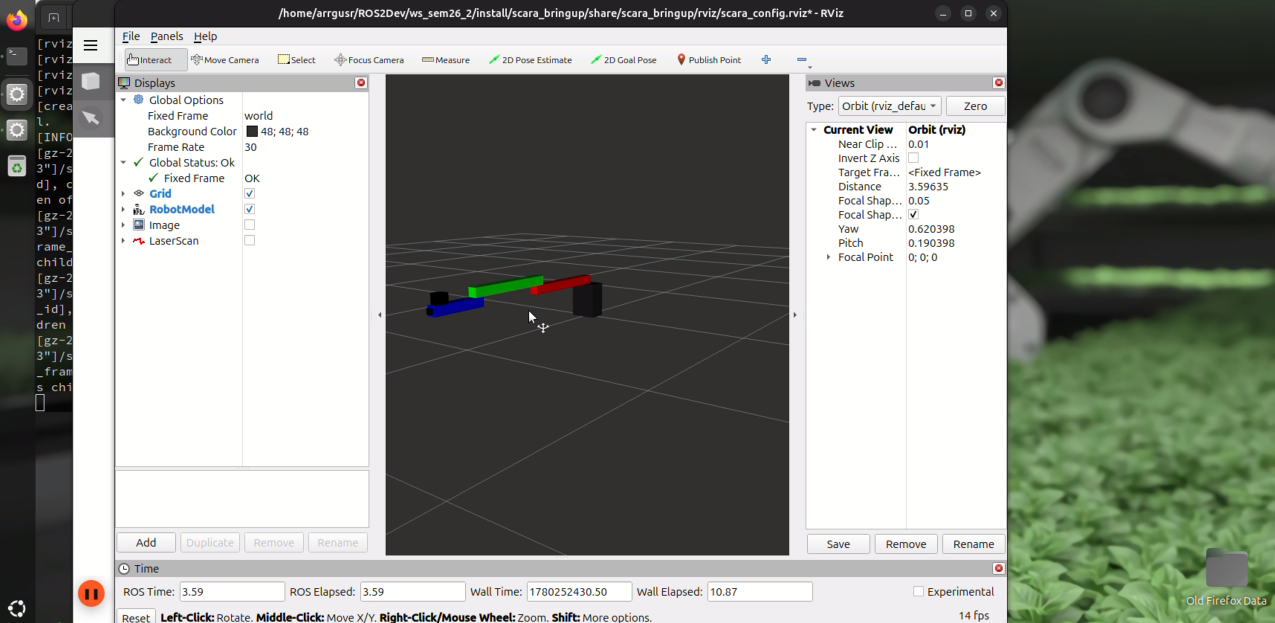
Figura 1. Interface de visualización de RVIZ para el robot construido en URDF.

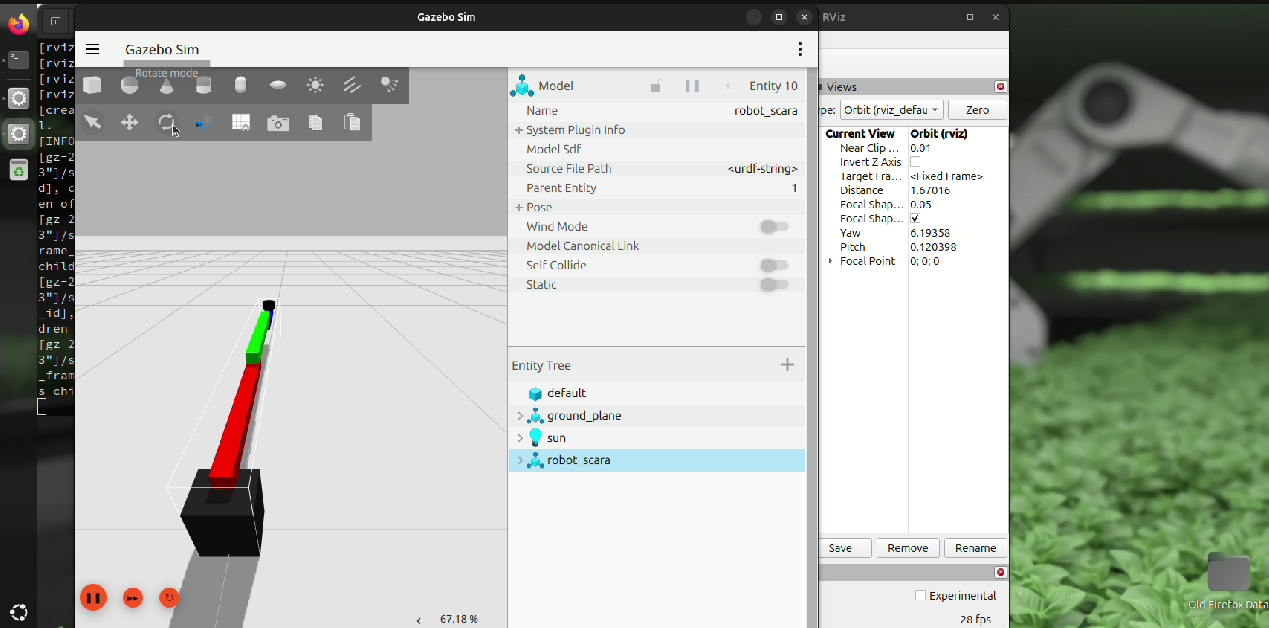
Figura 2. Interface de Gazebo con nuestro robot.




### Vídeos

[![Video de la práctica](https://i.ytimg.com/vi/fir66PXWC50/maxresdefault.jpg)](https://www.youtube.com/watch?v=fir66PXWC50)



## Conclusiones

En un contexto de desarrollo y análisis de posibles soluciones a problemas relacionados con la robótica, constantemente se necesita experimentar con geometrías y configuraciones de robots que, a menos que se cuente con una inversión ilimitada, no pueden construirse y probarse en la realidad. Por ello, la solución ha sido disponer de una herramienta que virtual que nos facilite el diseño de configuraciones y comportamientos de robots para atender tareas y problemas en la vida real. 

Como estudiantes de ingenería mecánica y mecatrónica, es imprescindible manejar el conocimiento básico de las herramientas unificadas de ROS2 para contruir pruebas virtuales, como en este caso lo son los archivos URDf, xacro y los comandos necesarios de ROS2 para hacer que estas construcciones en código se vean reflejadas en un visualizador como RVIZ o un simulador como Gazebo. 

Aunque en este casos se construyó un modelo relativamente sencillos, utilizando cajas y juntas bastante usuales, el ejercicio quedó como una base sólida para aprender el proceso de construcción de los robots que en un futuro podamos necesitar. En lo personal, estoy interesado por seguir investigando aspectos de este medio, me interesa descrubri qué tan complejo se vuelve describir la operación de un robot muchísimo más complejo, así como la posibilidad de importar modelos de CAD hacia un entorno de simulación.

Además de los aspectos necesarios, la repetición de la ejecución de los comandos para activar la simulación del robot se han aprendido de forma satisfactoria. El uso de la terminal como un medio directriz directo y eficaz para trabajar en ROS2 es una de las habilidades que más he aprendido a valorar, pues es interesante analizar el uso de una herramienta a la cual no estoy acostumbrado y que claramente es muchísimo más eficaz para estas aplicaciones.

El trabajo realizado para la generación de estos resultados también había atravesado peculiares problemáticas, como fallas en los monatajes de los paquetes y errores en la generación del espacio de trabajo, errores a los que se les encontró solución, ya sea analizando lso archivos y las fallas por errores de escritura, o a través de procesos más drásticos, como la creación de paquetes y códdigos totalmente distintos a los que en un principio se tenían. La complejidad de los trabja

## Bibliografía 

- [1] ROS 2 Documentation, “URDF,” ROS 2 Documentation. [En línea]. Disponible en: https://docs.ros.org/en/jazzy/Tutorials/Intermediate/URDF/URDF-Main.html. [Accedido: 23-may-2026].

- [2] ROS Wiki, “urdf,” ROS Wiki. [En línea]. Disponible en: https://wiki.ros.org/urdf. [Accedido: 23-may-2026].

- [3] ROS Wiki – XML/link, “urdf/XML/link,” ROS Wiki. [En línea]. Disponible en: https://wiki.ros.org/urdf/XML/link. [Accedido: 23-may-2026].

- [4] ROS Wiki – XML/joint, “urdf/XML/joint,” ROS Wiki. [En línea]. Disponible en: https://wiki.ros.org/urdf/XML/joint. [Accedido: 23-may-2026].

- [5] ROS 2 Documentation, “RViz User Guide,” ROS 2 Documentation. [En línea]. Disponible en: https://docs.ros.org/en/jazzy/Tutorials/Intermediate/RViz/RViz-User-Guide/RViz-User-Guide.html. [Accedido: 23-may-2026].

- [6] TurtleBot 4 User Manual, “RViz,” TurtleBot 4 User Manual. [En línea]. Disponible en: https://turtlebot.github.io/turtlebot4-user-manual/software/rviz.html. [Accedido: 23-may-2026].

